# Open-Weight LLMs on Your Machine

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## Running an LLM on Your Own Computer

- The model weights are a file on your disk: no account, no API key, no per-token bill, and nothing you type leaves the machine
- Open-weight models (Qwen, Llama, Gemma, Mistral, …) are released under licences that let anyone download and run them
- Seeing the pieces (weights, a runtime, an HTTP API) shows what a hosted service such as OpenAI’s is made of
- The programmatic workflow is the same as for a commercial API: the Python code in this deck runs against OpenAI or Google after changing three settings

## What We Will Install

- [Ollama](https://ollama.com): one MIT-licensed program that downloads weights, runs them, gives you a chat prompt, and serves an HTTP API
- The [`openai`](https://github.com/openai/openai-python) Python package: a client that speaks that API, installed with `uv`

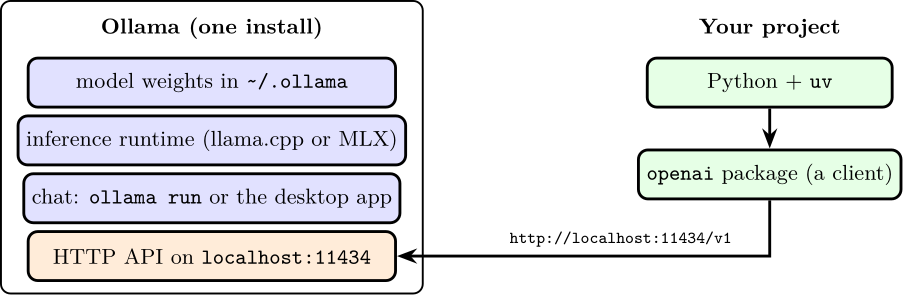

## Models and Memory

- A tag such as `2b` or `27b` gives the approximate number of parameters in billions
- **Quantization** stores weights at reduced precision: the models below use roughly four or eight bits per weight, making the download smaller than full-precision weights
- Apple Silicon Macs share one pool between CPU and GPU (**unified memory**). On Windows/Linux with a discrete GPU, its memory (**VRAM**) is separate from system RAM
- Ollama can also run on the CPU or split a model between CPU and GPU, at a cost in speed; leave room for the operating system and the conversation’s growing **KV cache**
- Local model tags run on your machine; tags ending in `:cloud` send prompts to a remote service and require an internet connection

## Suggested Models: September 2026

Starting points for short text demos; download sizes are **not total RAM usage**.

|      RAM | Computer                   | Model tag           |   Download |
|---------:|:---------------------------|:--------------------|-----------:|
| **8 GB** | **Any OS**                 | **`qwen3.5:2b`**    | **2.7 GB** |
|    16 GB | Any OS                     | `qwen3.5:4b`        |     3.4 GB |
|    32 GB | Any OS                     | `qwen3.5:9b`        |     6.6 GB |
|    48 GB | Apple Silicon Mac          | `qwen3.8:27b-mlx`   |      18 GB |
|    64 GB | Apple Silicon Mac          | `qwen3.8:27b-mxfp8` |      32 GB |
|   32+ GB | Windows/Linux, 24+ GB VRAM | `qwen3.8:27b`       |      18 GB |

- **Use `qwen3.5:2b` for this lecture.** With 8 GB, keep chats short (2K–4K context)
- CPU-only machines can use the first three rows, but larger models respond more slowly. The `mlx` and `mxfp8` choices above use MLX on Apple Silicon
- Current tags and sizes: [Qwen3.5](https://ollama.com/library/qwen3.5/tags), [Qwen3.8](https://ollama.com/library/qwen3.8/tags); [hardware](https://docs.ollama.com/gpu) and [context](https://docs.ollama.com/context-length) guidance

# Installing Ollama

## Install on macOS

- Download `ollama.dmg` from [ollama.com/download/mac](https://ollama.com/download/mac) and drag it to Applications, or, with [Homebrew](https://brew.sh) already installed,

``` bash
brew install --cask ollama-app
```

- Open Ollama from Applications and finish its first-run setup; keep it running. Alternatively, run `ollama serve` in a separate terminal and leave it open
- Then in another terminal

``` bash
ollama pull qwen3.5:2b   # download the weights once (2.7 GB)
ollama run qwen3.5:2b    # chat; /bye exits
```

- On a 48 GB Mac the large model is `ollama pull qwen3.8:27b-mlx` and `ollama run qwen3.8:27b-mlx`
- `pull` stores the weights in `~/.ollama`; `run` loads them into memory and opens a prompt; `ollama list` shows what you have

## Install on Windows (and Linux)

- Download and run `OllamaSetup.exe` from [ollama.com/download/windows](https://ollama.com/download/windows); the alternative `winget install --id Ollama.Ollama` uses a community-maintained package rather than an official one
- Then, in PowerShell, the same two commands as on macOS

``` powershell
ollama pull qwen3.5:2b
ollama run qwen3.5:2b
```

- Linux: `curl -fsSL https://ollama.com/install.sh | sh` installs a background service, then the same commands (a tarball for installs without root is on [docs.ollama.com/linux](https://docs.ollama.com/linux))
- The commands and API are the same across platforms; the MLX models in the table need an Apple Silicon Mac

## Chatting in the Terminal

- The same chat interface for every model: this screenshot shows `qwen3.5:4b` on a Linux workstation; use `ollama run qwen3.5:2b` on an 8 GB laptop

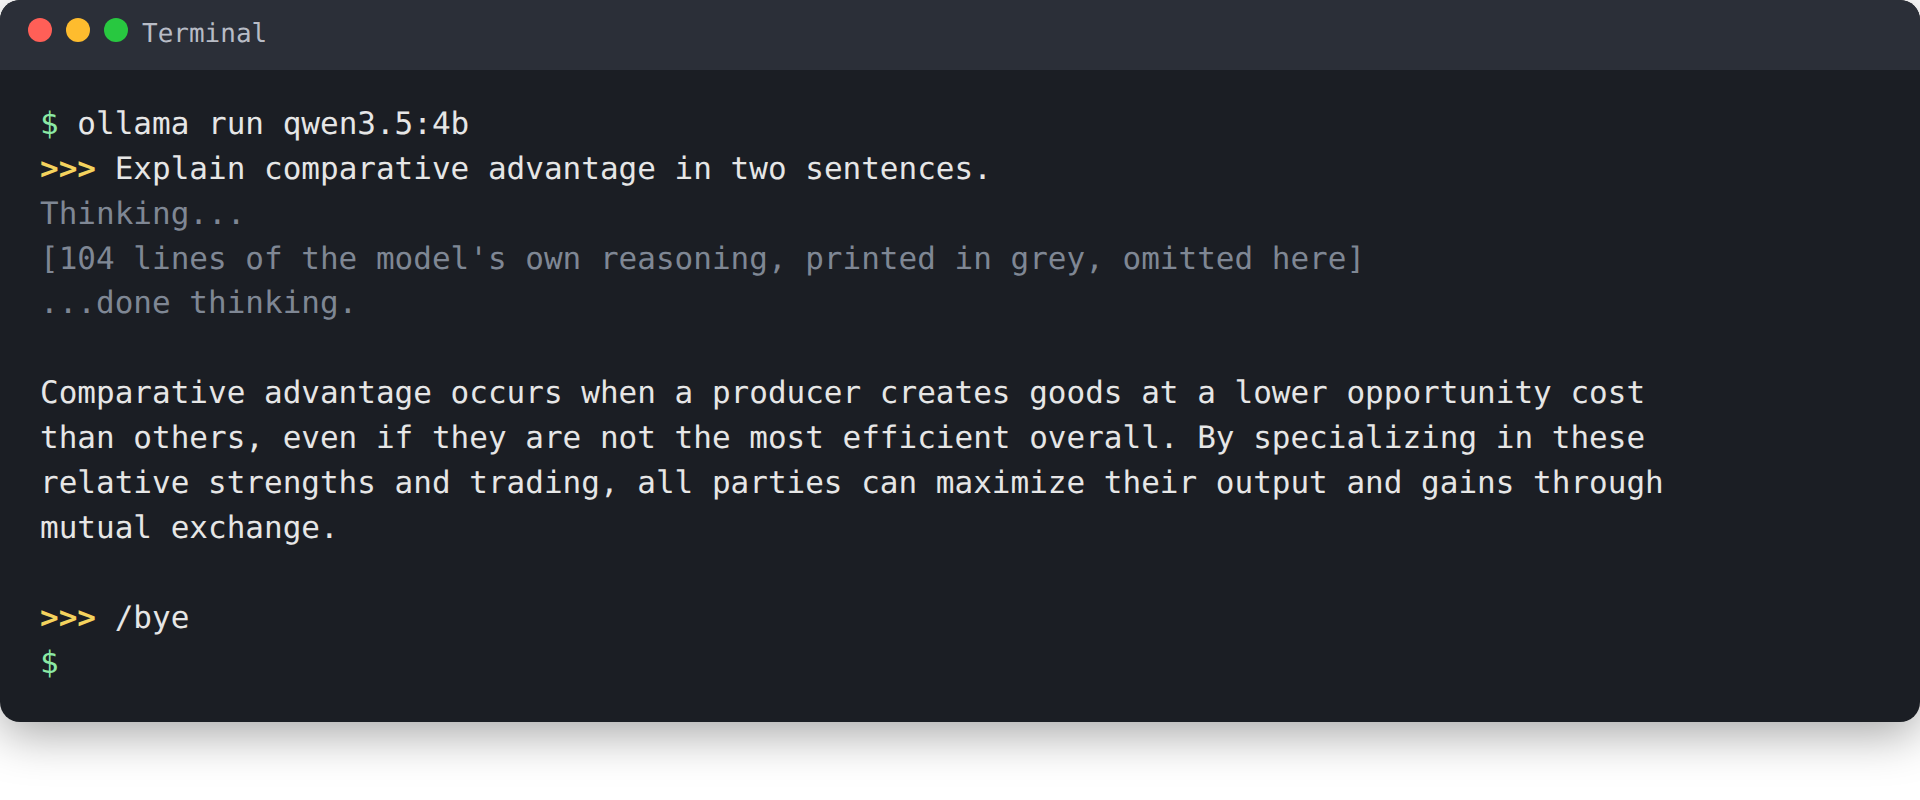

- On macOS and Windows the Ollama app also opens a chat window over the same models ([announcement](https://ollama.com/blog/new-app)); the terminal is what we use because it is identical everywhere

# Calling the Model from Python

## Same Model, Now Through Python

- In a new project (`uv init local-llm`, then `uv add openai` inside it), save the script below and `uv run python local_llm.py`

``` python
from openai import OpenAI

client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
question = "Explain comparative advantage in two sentences."
response = client.chat.completions.create(
    model="qwen3.5:2b",
    messages=[
        {"role": "system", "content": "You are a concise economics tutor."},
        {"role": "user", "content": question},
    ],
)
print(response.choices[0].message.content)
```

- The client requires an `api_key`, and Ollama ignores it, so any string works

## What Is Actually Happening

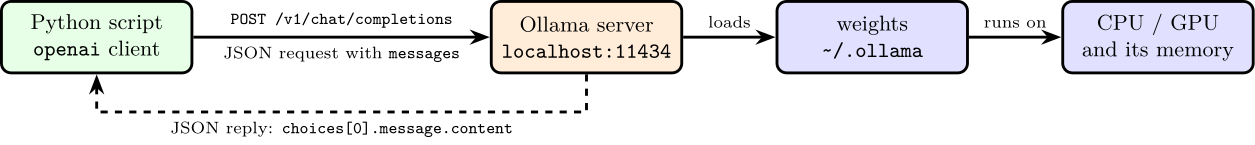

- The `openai` package is only a client: it turns the `messages` list into a JSON request, sends it over HTTP, and unpacks the JSON reply
- The request goes to `localhost`, so no request goes to OpenAI and nothing about your prompt leaves the machine
- The Ollama server does the work: it loads the weights, runs the model on the CPU or GPU, and returns the tokens

# Embeddings Redux

## A Local Embedding Model

- A chat model returns text; an **embedding model** maps text to a vector for similarity, classification, clustering, or retrieval
- Download a small embedding-specific model: `ollama pull qwen3-embedding:0.6b` (639 MB)
- The same OpenAI client now calls the `/v1/embeddings` endpoint

``` python
import numpy as np
from openai import OpenAI

client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
words = ["bank", "banks", "river", "money"]
response = client.embeddings.create(
    model="qwen3-embedding:0.6b", input=words
)
E = np.array([item.embedding for item in response.data])
print(E.shape)  # (4, 1024)
```

## Redo the “Bank” Comparison

The same words as the [earlier embeddings example](nlp_llm.html#/openai-embeddings), rerun in September 2026 with local Qwen (1,024D) and hosted OpenAI (3,072D):

- Both models put `bank` closest to `banks`, then `money`, then `river`
- Compare rankings within one embedding space. Absolute cosine values are not comparable across models because each model learns a different space
- Runnable local version: [`local_embeddings.py`](https://jlperla.github.io/grad_econ_datascience/code/local_embeddings.py)
- CI reads the committed cache. Refresh it with `uv run python utilities/build_embedding_comparison.py`, then render this deck with `--no-cache`

# One Client, Many Backends

## Why the OpenAI SDK for a Model that Is Not OpenAI’s?

- The shape of OpenAI’s chat API (`messages`, roles, `choices`) became a de facto standard; Ollama, Google, and most hosting services serve the same shape as a compatibility interface
- Everything that differs is three settings

| Backend | `base_url` | `api_key` | `model` |
|:-----------------|:-----------------|:-----------------|:-----------------|
| Ollama | `http://localhost:11434/v1` | any string | `qwen3.5:2b` |
| Google Gemini | `https://generativelanguage.googleapis.com/v1beta/openai/` | a Gemini key | `gemini-3.8-flash` |
| OpenAI | the default | an OpenAI key | `gpt-4o-mini` |

- The [NLP deck](nlp_llm.qmd) creates `OpenAI()` with the defaults (the last row); its chat and embedding code runs locally with the first row’s settings and a local embedding model name

- Basic chat is portable; provider-specific features are not (Ollama’s endpoint has no `logprobs` or `logit_bias`, Gemini’s compatibility layer is beta, and embedding model names differ)

## Same Code, Different Backend

- Three settings from the environment, Ollama by default: [`local_llm.py`](https://jlperla.github.io/grad_econ_datascience/code/local_llm.py)

``` python
import os
from openai import OpenAI

client = OpenAI(
    base_url=os.environ.get("LLM_BASE_URL", "http://localhost:11434/v1"),
    api_key=os.environ.get("LLM_API_KEY", "ollama"),
)
question = "Explain comparative advantage in two sentences."
response = client.chat.completions.create(
    model=os.environ.get("LLM_MODEL", "qwen3.5:2b"),
    messages=[
        {"role": "system", "content": "You are a concise economics tutor."},
        {"role": "user", "content": question},
    ],
)
print(response.choices[0].message.content)
```

- For OpenAI set `LLM_BASE_URL=https://api.openai.com/v1`, `LLM_MODEL=gpt-4o-mini`, and the key in `LLM_API_KEY`; the key never enters the file or git

## Things to Try and Extra Materials

- Change the system prompt; ask the same question with `temperature=0` and `temperature=1.5`; ask for JSON with `response_format={"type": "json_object"}`
- Run one prompt on the small and the large model and compare speed and quality; ask an economics question you know the answer to
- Point the script at another provider and check that only the three settings change
- References
  - [Ollama documentation](https://docs.ollama.com) and its [OpenAI compatibility](https://docs.ollama.com/api/openai-compatibility) page
  - Local embeddings: [`qwen3-embedding:0.6b`](https://ollama.com/library/qwen3-embedding:0.6b) and Ollama’s [`/api/embed`](https://docs.ollama.com/api/embed) documentation
  - Model cards [Qwen3.5-2B](https://huggingface.co/Qwen/Qwen3.5-2B) and [Qwen3.8-27B](https://huggingface.co/Qwen/Qwen3.8-27B); Ollama tags [`qwen3.5`](https://ollama.com/library/qwen3.5) and [`qwen3.8`](https://ollama.com/library/qwen3.8)
  - [Gemini’s OpenAI compatibility](https://ai.google.dev/gemini-api/docs/openai) and the [`openai` Python SDK](https://github.com/openai/openai-python)

# Orchestration Frameworks

## LangChain as an Example

- Every call in the NLP and text classification decks is one hand-built request: a `messages` list of role dicts, a loop over articles, a comprehension over `response.data`
- [LangChain](https://python.langchain.com/) wraps these in composable objects
  - `ChatOpenAI` bundles the client, model, and settings
  - `SystemMessage`, `HumanMessage`, and `AIMessage` replace the role dicts
  - `.batch(..., config={"max_concurrency": 3})` replaces the classifier loop and adds concurrency and retries
  - The same `.invoke` works on `ChatAnthropic` or `ChatGoogleGenerativeAI`, whose wire formats are not OpenAI-compatible
- Runnable version against Ollama: [`langchain_chat.py`](https://jlperla.github.io/grad_econ_datascience/code/langchain_chat.py), after `uv sync --extra extras` in the course repository

## When It Pays Off

- Multi-step pipelines: prompt template, then model, then output parser
- Structured output parsed into typed objects
- Retrieval-augmented generation: embed documents, store them, retrieve the closest into the prompt
- Agents that call tools in a loop
- Costs: another vocabulary, a large dependency tree, and a fast-changing API
  - For one request per slide the raw client is shorter, and the `messages` list is what every framework sends anyway
- Same idea elsewhere: [LlamaIndex](https://www.llamaindex.ai/) and [DSPy](https://dspy.ai/)